# Topic Classification with Transformers

This notebook compares a transformer-based RoBERTa classifier with a classical Naive Bayes text classifier on a subset of the 20 Newsgroups dataset.

The focus is on end-to-end topic classification, evaluation with precision/recall/F1, and comparison between neural and conventional machine learning approaches.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import classification_report
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt
import seaborn as sn

### Getting and splitting the data

In [2]:
from sklearn.datasets import fetch_20newsgroups

# load only a sub-selection of the categories (4 in our case)
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']

# remove the headers, footers and quotes (to avoid overfitting)
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)

In [4]:
train = pd.DataFrame({'text': newsgroups_train.data, 'labels': newsgroups_train.target})
test = pd.DataFrame({'text': newsgroups_test.data, 'labels': newsgroups_test.target})

In [5]:
from sklearn.model_selection import train_test_split

train, dev = train_test_split(train, test_size=0.1, random_state=0,
                               stratify=train[['labels']])

## **roBERTa model**

### Defining Model

In [6]:
# Model configuration # https://simpletransformers.ai/docs/usage/#configuring-a-simple-transformers-model
model_args = ClassificationArgs()

model_args.overwrite_output_dir=True # overwrite existing saved models in the same directory
model_args.evaluate_during_training=True # to perform evaluation while training the model
# (eval data should be passed to the training method)

model_args.num_train_epochs=10 # number of epochs
model_args.train_batch_size=32 # batch size
model_args.learning_rate=4e-6 # learning rate
model_args.max_seq_length=256 # maximum sequence length
# Note! Increasing max_seq_len may provide better performance, but training time will increase.
# For educational purposes, we set max_seq_len to 256.

# Early stopping to combat overfitting: https://simpletransformers.ai/docs/tips-and-tricks/#using-early-stopping
model_args.use_early_stopping=True
model_args.early_stopping_delta=0.01 # "The improvement over best_eval_loss necessary to count as a better checkpoint"
model_args.early_stopping_metric='eval_loss'
model_args.early_stopping_metric_minimize=True
model_args.early_stopping_patience=2
model_args.evaluate_during_training_steps=32 # how often you want to run validation in terms of training steps (or batches)

In [7]:
import torch

use_cuda = torch.cuda.is_available()
model = ClassificationModel("roberta", "roberta-base", num_labels=4, args=model_args, use_cuda=use_cuda)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

### Training model

In [8]:
_, history = model.train_model(train, eval_df=dev)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Running Epoch 1 of 10:   0%|          | 0/64 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Running Epoch 7 of 10:   0%|          | 0/64 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

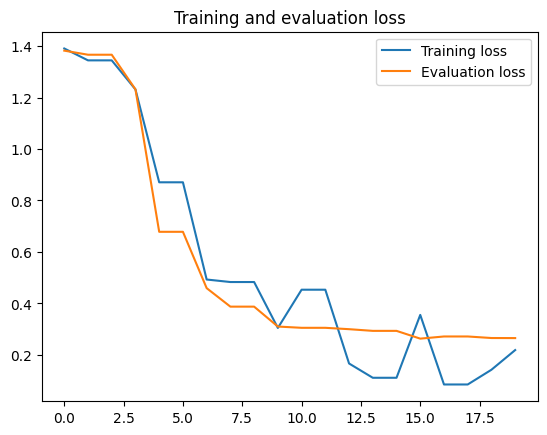

In [9]:
# Training and evaluation loss
train_loss = history['train_loss']
eval_loss = history['eval_loss']
plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

### Evaluating model

In [10]:
# Evaluate the model
result, model_outputs, wrong_predictions = model.eval_model(dev)
result

0it [00:00, ?it/s]

Running Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

{'mcc': 0.8467153052513751, 'eval_loss': 0.2654668639103572}

In [11]:
predicted, probabilities = model.predict(test.text.to_list())
test['predicted'] = predicted

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

In [12]:
print(classification_report(test['labels'], test['predicted']))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       319
           1       0.90      0.92      0.91       389
           2       0.86      0.91      0.88       396
           3       0.88      0.80      0.84       394

    accuracy                           0.87      1498
   macro avg       0.86      0.86      0.86      1498
weighted avg       0.87      0.87      0.87      1498



---

## **SVM/Naive Bayes model**

In [6]:
### Implement an SVM/Naive Bayes model for topic classification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score

# Pipeline for Naive Bayes
nb_pipeline = make_pipeline(TfidfVectorizer(stop_words='english', max_features=10000), MultinomialNB())

# Fit the model
nb_pipeline.fit(train['text'], train['labels'])

# Evaluate the model on the development set
dev_preds_nb = nb_pipeline.predict(dev['text'])
nb_accuracy = accuracy_score(dev['labels'], dev_preds_nb)

print("Naive Bayes Classification Report:")
print(classification_report(dev['labels'], dev_preds_nb))

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.93        48
           1       0.89      0.93      0.91        59
           2       0.94      0.97      0.95        60
           3       0.86      0.85      0.85        59

    accuracy                           0.91       226
   macro avg       0.92      0.91      0.91       226
weighted avg       0.91      0.91      0.91       226



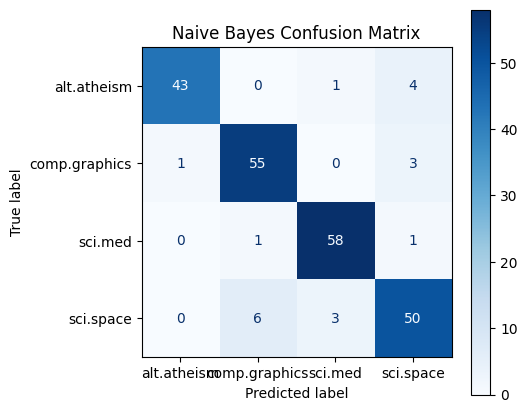

C:\Users\Mees\AppData\Local\Temp\ipykernel_16276\3037866681.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


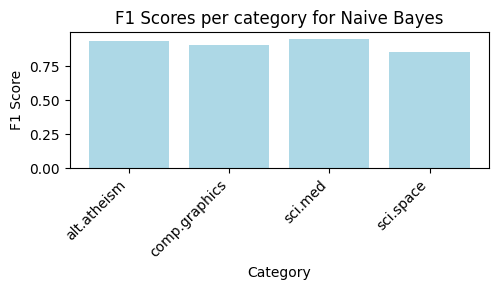

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

# Generating predictions
dev_preds_nb = nb_pipeline.predict(dev['text'])

# Confusion matrix
cm = confusion_matrix(dev['labels'], dev_preds_nb)
labels = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']

# Plot confusion matrix plot
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax)
plt.title('Naive Bayes Confusion Matrix')
plt.show()

# F1 scores calculated and plotted in a bar chart
f1_scores = f1_score(dev['labels'], dev_preds_nb, average=None)
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(labels, f1_scores, )
ax.set_xlabel('Category')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Scores per category for Naive Bayes')
ax.tick_params(axis='x', labelrotation=45)
plt.tight_layout()
plt.show()

## **Comparing the models**

Report for roBERTa:
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       319
           1       0.90      0.92      0.91       389
           2       0.86      0.91      0.88       396
           3       0.88      0.80      0.84       394

    accuracy                           0.87      1498
    macro avg       0.86      0.86      0.86      1498
    weighted avg       0.87      0.87      0.87      1498

Report for Naive Bayes:
precision    recall  f1-score   support

           0       0.98      0.90      0.93        48
           1       0.89      0.93      0.91        59
           2       0.94      0.97      0.95        60
           3       0.86      0.85      0.85        59

    accuracy                           0.91       226
    macro avg       0.92      0.91      0.91       226
    weighted avg       0.91      0.91      0.91       226

### Accuracy:
RoBERTa: 87%
Naive Bayes: 91%

As we can see, both models have a good accuracy score, however the Naive bias model's socore is slightly higher. Practically this could be important to a task such as email spam detection where the higher accuracy will lead to less false positives.

### Precision, Recall, F1-score:
#### RoBERTa:
- Precision: Ranges from 0.83 to 0.90
- Recall: Ranges from 0.80 to 0.92
- F1-score: Ranges from 0.83 to 0.91

#### Naive Bayes:
- Precision: Ranges from 0.86 to 0.98
- Recall: Ranges from 0.85 to 0.97
- F1-score: Ranges from 0.85 to 0.95

In terms of precision, Recall, and F1-score we can see that the range of scores for Naive Bayes is higher. This indicates that the model is slightly better. We need to consider the support scores for both models. RoBERTa has a much higher score for each class as well as a higher macro and weighted average. Such a large count for support indicates that there may be class inbalance skewing the results which does not occur as much for the Naieve Bayes model. 

Despite Naive Bayes outperforming RoBERTa in terms of precision, recall, and F1-scores, the choice between the two models depends on various factors. Naive Bayes, being a simpler probabilistic model, offers computational efficiency and interpretability, making it suitable for tasks where resource constraints and model transparency are critical. On the other hand, RoBERTa may require more computational resources but offers great performance and versatility across various natural language processing tasks.